In [14]:
import os

dataset_path = "lemon_leaf_dataset"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

train_total = 0
test_total = 0
for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    
    if os.path.isdir(class_folder):
        train_total += len(os.listdir(class_folder))

print("Total TRAIN images:", train_total)
for class_name in os.listdir(test_path):
    class_folder = os.path.join(test_path, class_name)
    
    if os.path.isdir(class_folder):
        test_total += len(os.listdir(class_folder))

print("Total TEST images:", test_total)
print("TOTAL IMAGES (TRAIN + TEST):", train_total + test_total)

Total TRAIN images: 6913
Total TEST images: 1731
TOTAL IMAGES (TRAIN + TEST): 8644


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

In [19]:
#lemon dataset path
dataset_path = "lemon_leaf_dataset"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
#parameter
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 9

In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [21]:
#data preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [22]:
#load dataset for train
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 6913 images belonging to 9 classes.


In [23]:
#load dataset for test
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1731 images belonging to 9 classes.


In [ ]:
#effeicient 
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [28]:
#custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)

output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [29]:
#compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
EPOCHS = 20

history = model.fit(
    train_data,
    validation_data=train_data,
    epochs=EPOCHS
)

Epoch 1/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 167s 756ms/step - accuracy: 0.6590 - loss: 1.0859 - val_accuracy: 0.8250 - val_loss: 0.5625
Epoch 2/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 188s 865ms/step - accuracy: 0.8352 - loss: 0.5195 - val_accuracy: 0.8817 - val_loss: 0.3774
Epoch 3/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 187s 861ms/step - accuracy: 0.8698 - loss: 0.3933 - val_accuracy: 0.9070 - val_loss: 0.3036
Epoch 4/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 182s 841ms/step - accuracy: 0.8892 - loss: 0.3359 - val_accuracy: 0.9142 - val_loss: 0.2641
Epoch 5/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 180s 830ms/step - accuracy: 0.8992 - loss: 0.2976 - val_accuracy: 0.9340 - val_loss: 0.2283
Epoch 6/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 147s 679ms/step - accuracy: 0.9103 - loss: 0.2730 - val_accuracy: 0.9293 - val_loss: 0.2141
Epoch 7/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 151s 699ms/step - accuracy: 0.9210 - loss: 0.2507 - val_accuracy: 0.9400 - val_loss: 0.1979
Epoch 8/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 166s 763ms/step - accuracy: 0.9238 -

In [31]:
loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)

55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 380ms/step - accuracy: 0.9630 - loss: 0.1165

Test Accuracy: 0.9630271792411804
Test Loss: 0.11647847294807434


In [32]:
model.save(
    "efficientnet_lemon_disease.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


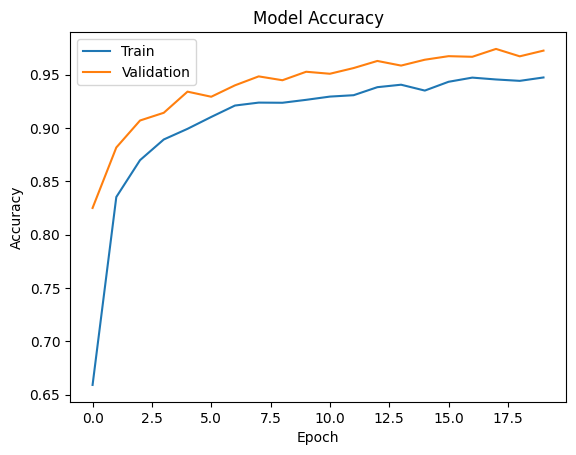

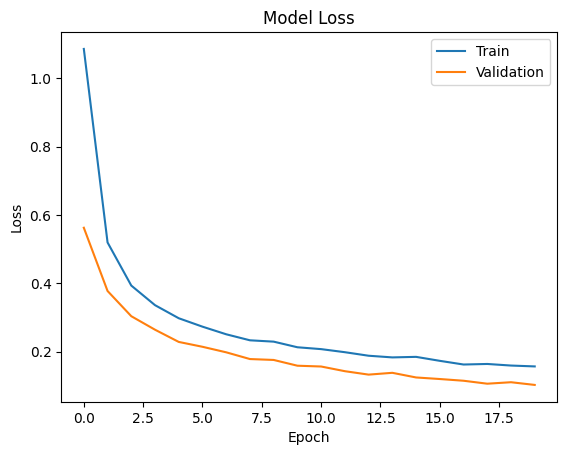

In [33]:
#Performance graphs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

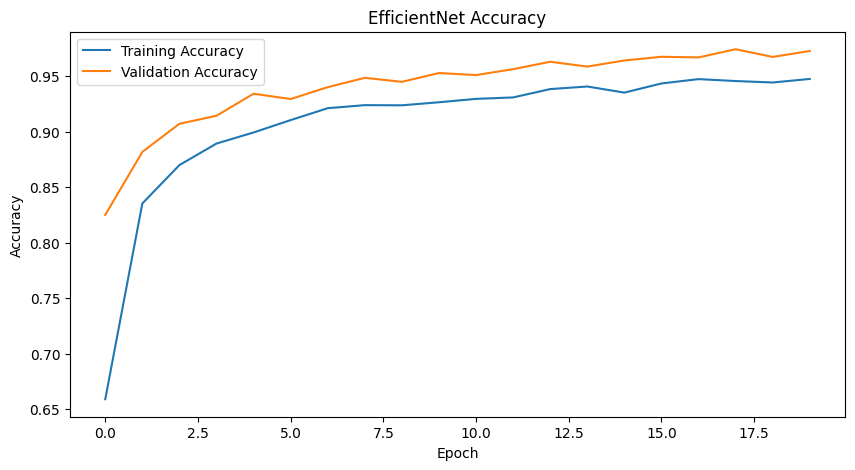

In [34]:

#Accuracy Graph
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet Accuracy")
plt.legend()

plt.show()

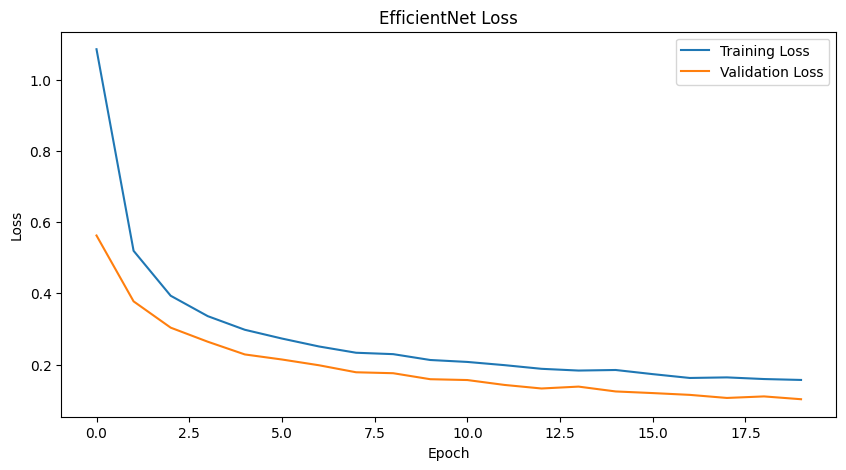

In [35]:
#loss graph
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet Loss")
plt.legend()

plt.show()

In [36]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 291ms/step
[[171   0  16   4   0   0   1   0   0]
 [  0 197   0   0   0   0   0   0   0]
 [  0   0 177   5   1   0   1   0   0]
 [  0   0  11 163   8   0   0   0   0]
 [  2   0   3   9 169   0   2   0   0]
 [  0   0   0   0   0 198   0   0   0]
 [  0   0   0   0   0   0 193   0   0]
 [  0   0   0   0   0   0   0 200   0]
 [  0   1   0   0   0   0   0   0 199]]
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       192
           1       0.99      1.00      1.00       197
           2       0.86      0.96      0.91       184
           3       0.90      0.90      0.90       182
           4       0.95      0.91      0.93       185
           5       1.00      1.00      1.00       198
           6       0.98      1.00      0.99       193
           7       1.00      1.00      1.00       200
           8       1.00      0.99      1.00       200

    accuracy                           0.96      1731
   macro a